Shape: (200, 5)


,customer_id,gender,age,annual_income_k,spending_score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   customer_id      200 non-null    int64 
 1   gender           200 non-null    object
 2   age              200 non-null    int64 
 3   annual_income_k  200 non-null    int64 
 4   spending_score   200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB



,customer_id,gender,age,annual_income_k,spending_score
count,200.000000,200,200.000000,200.000000,200.000000
unique,NaN,2,NaN,NaN,NaN
top,NaN,Female,NaN,NaN,NaN
freq,NaN,112,NaN,NaN,NaN
mean,100.500000,NaN,38.850000,60.560000,50.200000
std,57.879185,NaN,13.969007,26.264721,25.823522
min,1.000000,NaN,18.000000,15.000000,1.000000
25%,50.750000,NaN,28.750000,41.500000,34.750000
50%,100.500000,NaN,36.000000,61.500000,50.000000
75%,150.250000,NaN,49.000000,78.000000,73.000000


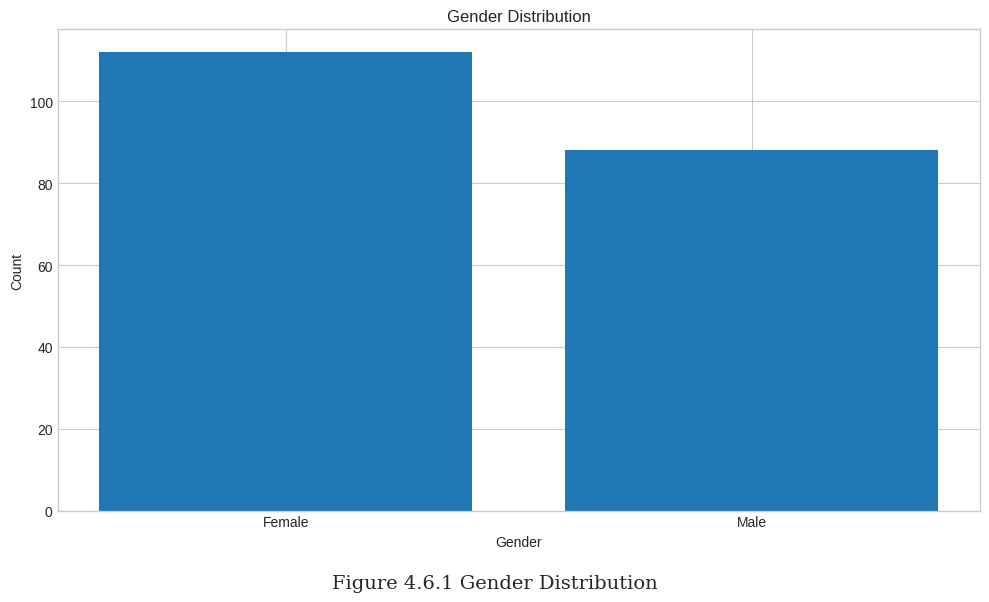

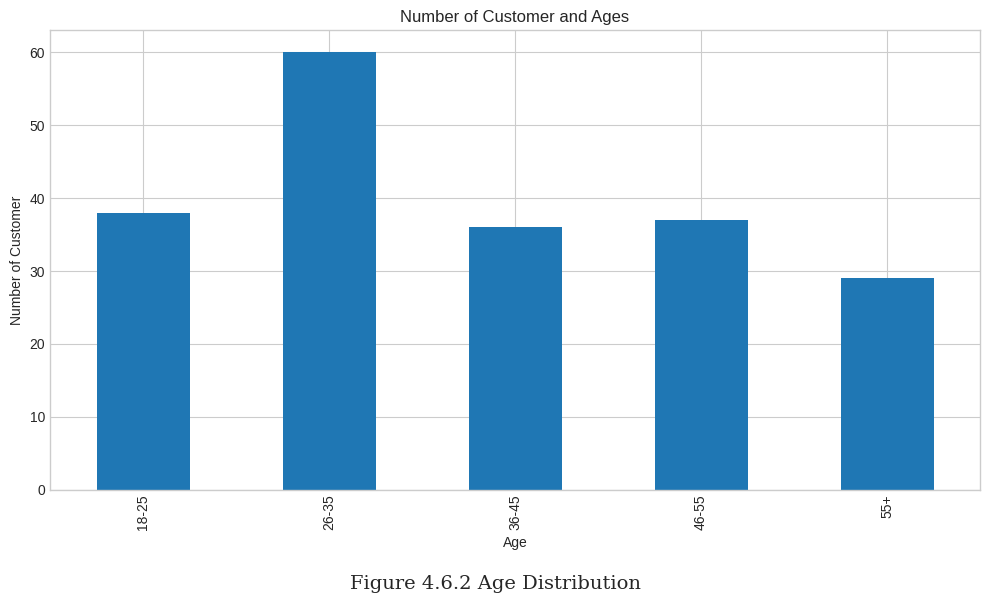

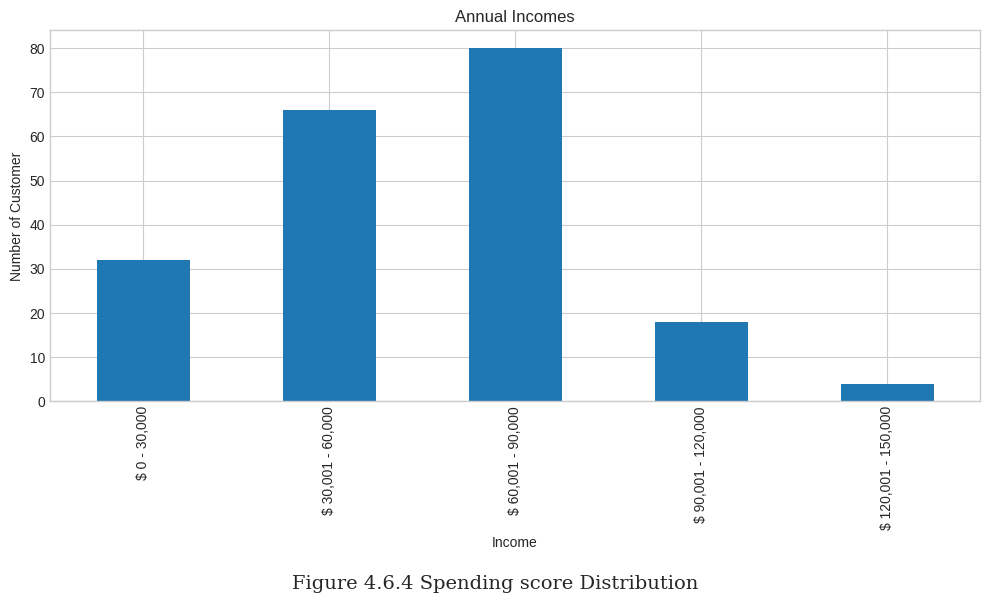

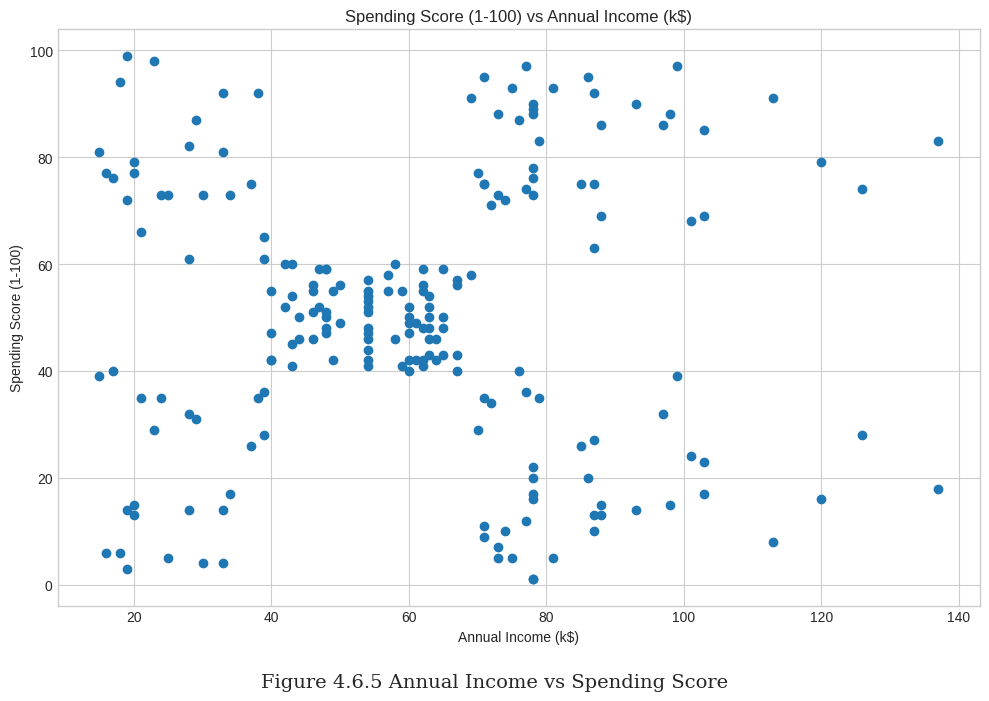

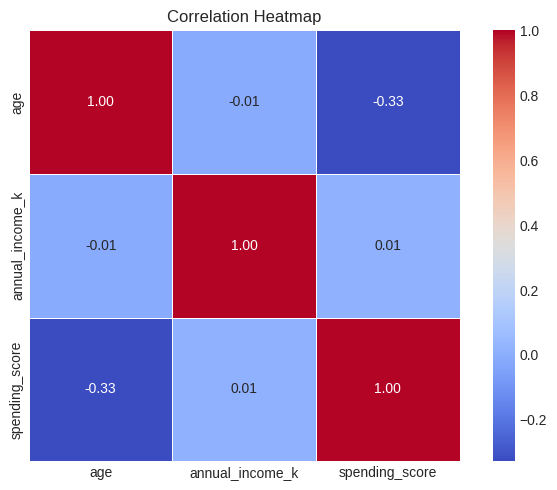

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

DATA_URL = "https://raw.githubusercontent.com/Alfukhan0/Mall_customers_dataset/refs/heads/main/Cleaned_Mall_Customers.csv"

# Load dataset
df = pd.read_csv(DATA_URL)
df.columns = df.columns.str.strip()

def add_caption(text):
    plt.figtext(0.5, 0.01, text, ha='center', fontsize=14, family='serif')

# Preview
print("Shape:", df.shape)
display(df.head())
df.info()
print()
display(df.describe(include='all'))

# ── Figure 4.6.1: Gender Distribution ─────────────────────
gender_counts = df['gender'].value_counts()

plt.figure(figsize=(10, 6))
plt.bar(gender_counts.index, gender_counts.values)
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.tight_layout(rect=[0, 0.05, 1, 1])
add_caption("Figure 4.6.1 Gender Distribution")
plt.show()

# ── Figure 4.6.2: Age Distribution ────────────────────────
age_bins = [17, 25, 35, 45, 55, 100]
age_labels = ['18-25', '26-35', '36-45', '46-55', '55+']
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels, include_lowest=True)

plt.figure(figsize=(10, 6))
df['age_group'].value_counts().sort_index().plot(kind='bar')
plt.title("Number of Customer and Ages")
plt.xlabel("Age")
plt.ylabel("Number of Customer")
plt.tight_layout(rect=[0, 0.05, 1, 1])
add_caption("Figure 4.6.2 Age Distribution")
plt.show()
# ── Figure 4.6.4: Annual Incomes ──────────────────────────
income_bins = [0, 30, 60, 90, 120, 150]
income_labels = ['$ 0 - 30,000', '$ 30,001 - 60,000', '$ 60,001 - 90,000', '$ 90,001 - 120,000', '$ 120,001 - 150,000']
df['income_group'] = pd.cut(df['annual_income_k'], bins=income_bins, labels=income_labels, include_lowest=True)

plt.figure(figsize=(10, 6))
df['income_group'].value_counts().sort_index().plot(kind='bar')
plt.title("Annual Incomes")
plt.xlabel("Income")
plt.ylabel("Number of Customer")
plt.tight_layout(rect=[0, 0.05, 1, 1])
add_caption("Figure 4.6.4 Spending score Distribution")
plt.show()

# ── Figure 4.6.5: Annual Income vs Spending Score ─────────
plt.figure(figsize=(10, 7))
plt.scatter(df['annual_income_k'], df['spending_score'])
plt.title("Spending Score (1-100) vs Annual Income (k$)")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.tight_layout(rect=[0, 0.05, 1, 1])
add_caption("Figure 4.6.5 Annual Income vs Spending Score")
plt.show()

# ── Correlation Heatmap ────────────────────────────────────
numeric_df = df[['age', 'annual_income_k', 'spending_score']]
corr = numeric_df.corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True, linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()